In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the hotel_bookings.csv file into a pandas DataFrame
df_master = pd.read_csv('/content/hotel_bookings.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/hotel_bookings.csv'

### Data Information

In [ ]:
# Display concise summary of the DataFrame
display(df_master.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

### Descriptive Statistics

In [ ]:
print("Value counts for 'is_canceled':")
print(df_master['is_canceled'].value_counts())

print("\nPercentage of 'is_canceled':")
print(df_master['is_canceled'].value_counts(normalize=True) * 100)

Value counts for 'is_canceled':
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Percentage of 'is_canceled':
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


In [ ]:
# Generate descriptive statistics
display(df_master.describe())

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### DataFrame Shape and Duplicates

In [ ]:
# Display the shape of the DataFrame
print(f"Initial DataFrame shape: {df_master.shape}")

# Check for duplicates
num_duplicates = df_master.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Drop duplicate rows
df_master.drop_duplicates(inplace=True)
print(f"DataFrame shape after dropping duplicates: {df_master.shape}")

Initial DataFrame shape: (119390, 32)
Number of duplicate rows: 31994
DataFrame shape after dropping duplicates: (87396, 32)


### Handling Missing Values: `children` and `country`

As discussed in the data science strategy, we will impute the missing values for `children` and `country` to maintain data integrity and avoid bias.

*   **`children`**: Impute the 4 missing values with `0.0` (its mode).
*   **`country`**: Impute the 488 missing values with `'PRT'` (its mode).

In [ ]:
# Impute missing values in 'children' with 0.0
df_master['children'].fillna(0.0, inplace=True)

# Impute missing values in 'country' with 'PRT' (Portugal, the mode)
df_master['country'].fillna('PRT', inplace=True)

print("Missing values after imputation:")
print(df_master[['children', 'country']].isnull().sum())

Missing values after imputation:
children    0
country     0
dtype: int64


/tmp/ipykernel_2594/2282288162.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0.0, inplace=True)


### Null Values in Specified Columns

In [ ]:
# Define the range of columns to check for nulls
columns_to_check = df_master.loc[:, 'adults':'previous_bookings_not_canceled'].columns

# Check for null values in these specific columns
null_counts = df_master[columns_to_check].isnull().sum()
display(null_counts[null_counts > 0])

,0
children,4
country,452


### Univariate Analysis: `adults`

In [ ]:
# Check the frequency distribution of adults per booking
df_master['adults'].value_counts().sort_index()

,count
adults,
0,385
1,16503
2,64497
3,5935
4,60
5,2
6,1
10,1
20,2


In [ ]:
# Calculate the percentage of bookings for each number of adults
adult_dist = df_master['adults'].value_counts(normalize=True).sort_index() * 100
adult_dist.round(2)

,proportion
adults,
0,0.44
1,18.88
2,73.80
3,6.79
4,0.07
5,0.00
6,0.00
10,0.00
20,0.00


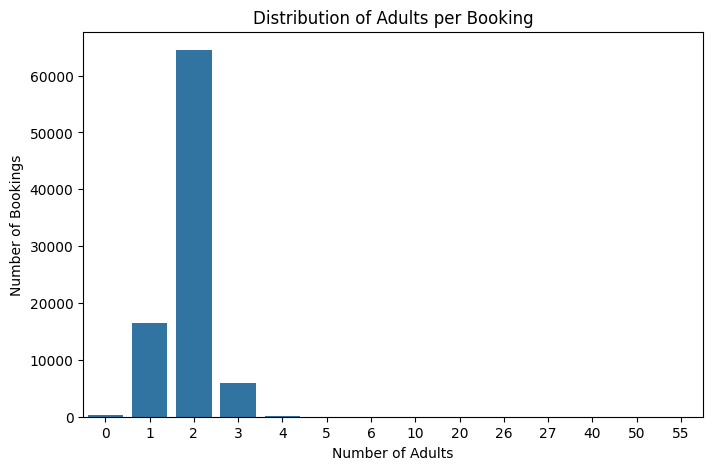

In [ ]:
# Visualize the number of adults per booking
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='adults')
plt.title('Distribution of Adults per Booking')
plt.xlabel('Number of Adults')
plt.ylabel('Number of Bookings')
plt.show()

**Most common:** 2 adults (around 75% of bookings), followed by 1 adult (around 20%)
Very few bookings with 0 adults (these might be bookings for children/babies only, or data errors) or more than 2 adults.

### Univariate Analysis: `children`

In [ ]:
# Check the frequency distribution of children per booking
df_master['children'].value_counts(dropna=False).sort_index()

,count
children,
0.0,79032
1.0,4695
2.0,3593
3.0,75
10.0,1


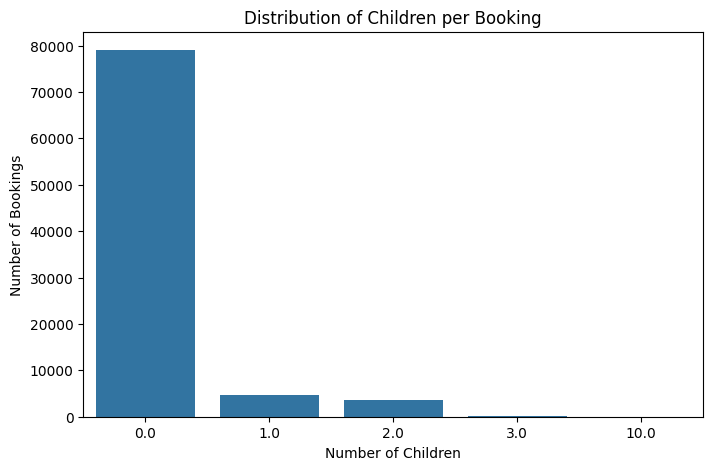

In [ ]:
# Visualize the number of children per booking
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='children')
plt.title('Distribution of Children per Booking')
plt.xlabel('Number of Children')
plt.ylabel('Number of Bookings')

plt.show()

**0 children (over 90% of bookings).
Very few bookings include 1, 2, 3, or 10 children. The value '10' for children might be an outlier or data error.**

### Univariate Analysis: `babies`

In [ ]:
# Check the frequency distribution of babies per booking
df_master['babies'].value_counts(dropna=False).sort_index()

,count
babies,
0,86482
1,897
2,15
9,1
10,1


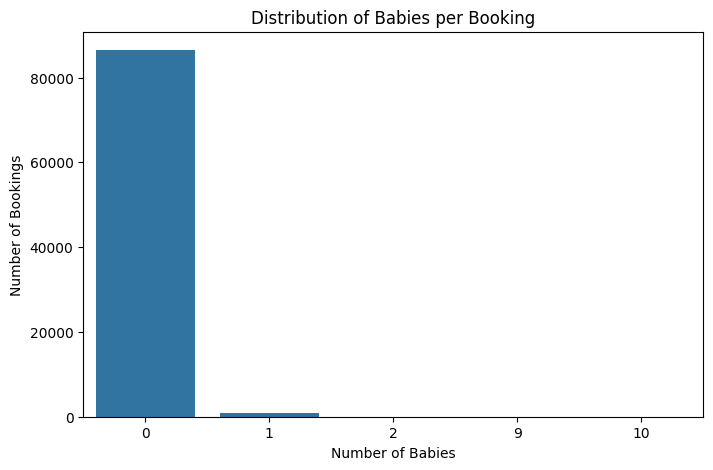

In [ ]:
# Visualize the number of babies per booking
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='babies')

plt.title('Distribution of Babies per Booking')
plt.xlabel('Number of Babies')
plt.ylabel('Number of Bookings')
plt.show()

 0 babies (over 99% of bookings).

Very few bookings include 1, 2, or 10 babies. The value '10' for babies might be an outlier or data error.
Business Meaning:

Bookings with babies are extremely rare in this dataset.

This feature is highly sparse and skewed.

### Univariate Analysis: `meal`

In [ ]:
# Check the number of bookings for each meal type
df_master['meal'].value_counts(dropna=False)

,count
meal,
BB,67978
SC,9481
HB,9085
Undefined,492
FB,360


In [ ]:
# Calculate the percentage of bookings for each meal type
meal_pct = (df_master['meal'].value_counts(normalize=True, dropna=False).mul(100).round(2))
meal_pct

,proportion
meal,
BB,77.78
SC,10.85
HB,10.40
Undefined,0.56
FB,0.41


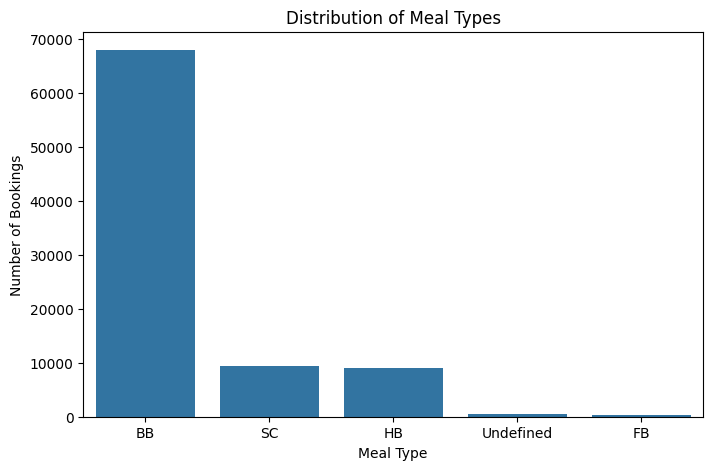

In [ ]:
# Visualize the distribution of meal types
plt.figure(figsize=(8, 5))

sns.countplot(data=df_master, x='meal', order=df_master['meal'].value_counts().index)

plt.title('Distribution of Meal Types')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')
plt.show()

* BB is the dominant meal type, accounting for approximately 78% of bookings, while SC and HB each account for around 11%. FB and Undefined bookings are rare.

* The highly imbalanced distribution should be considered when comparing cancellation rates across meal types.*

### Univariate Analysis: `country`

In [ ]:
# Check the frequency distribution of bookings by country
# Note: The 'country' column has 452 null values, which will be excluded from the counts.
display(df_master['country'].value_counts().head(10)) # Display top 10 countries for brevity

,count
country,
PRT,27905
GBR,10433
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081
BRA,1995


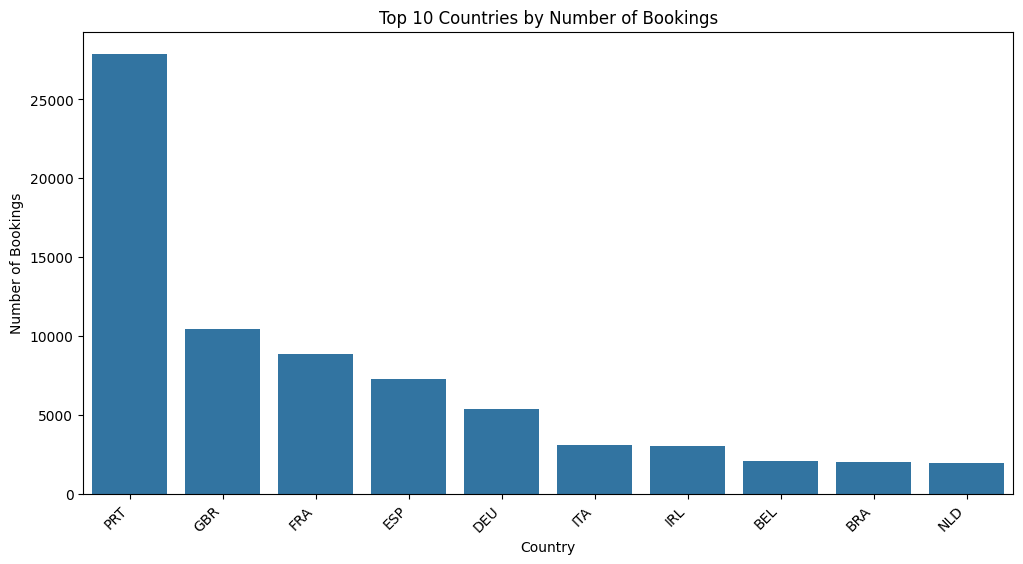

In [ ]:
# Visualize the distribution of bookings by country (Top 10)
plt.figure(figsize=(12, 6))
sns.countplot(data=df_master, x='country', order=df_master['country'].value_counts().head(10).index)
plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.show()

####
**PRT (Portugal)**: Dominates by far, being the country of origin for the majority of bookings.

Other European countries like GBR (United Kingdom), FRA (France), ESP (Spain), DEU (Germany) follow, but with significantly fewer bookings.

There's an 'Unknown' category, which indicates records where the country information was missing.

The dataset is heavily skewed towards bookings from Portugal, likely indicating the location of the hotels or a primary target market.

### Univariate Analysis: `market_segment`

In [ ]:
# Check the frequency distribution of bookings by market segment
display(df_master['market_segment'].value_counts())

,count
market_segment,
Online TA,51618
Offline TA/TO,13889
Direct,11804
Groups,4942
Corporate,4212
Complementary,702
Aviation,227
Undefined,2


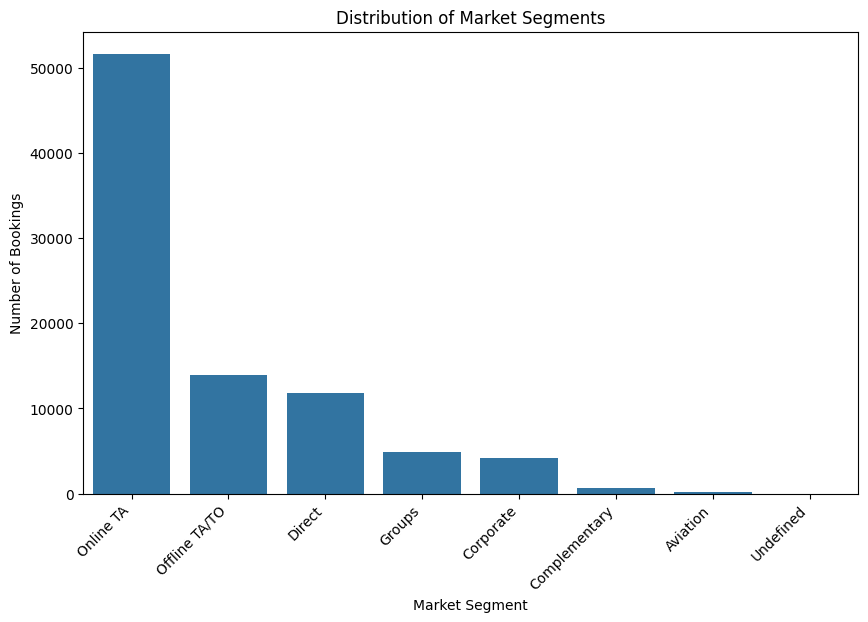

In [ ]:
# Visualize the distribution of market segments
plt.figure(figsize=(10, 6))
sns.countplot(data=df_master, x='market_segment', order=df_master['market_segment'].value_counts().index)
plt.title('Distribution of Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.show()

####
**Online TA (Travel Agents):** The dominant market segment, accounting for the largest share of bookings.

**Offline TA/TO (Travel Agents/Tour Operators)** and **Groups** are the next significant segments.

**Direct** and **Corporate** bookings are also present but less frequent.

Complementary and Aviation are very rare.

* Online travel agents are the primary channel for acquiring guests.
* Different market segments represent distinct customer behaviors and booking processes.

### Univariate Analysis: `distribution_channel`

In [ ]:
# Check the frequency distribution of bookings by distributed channel
display(df_master['distribution_channel'].value_counts())

,count
distribution_channel,
TA/TO,69141
Direct,12988
Corporate,5081
GDS,181
Undefined,5


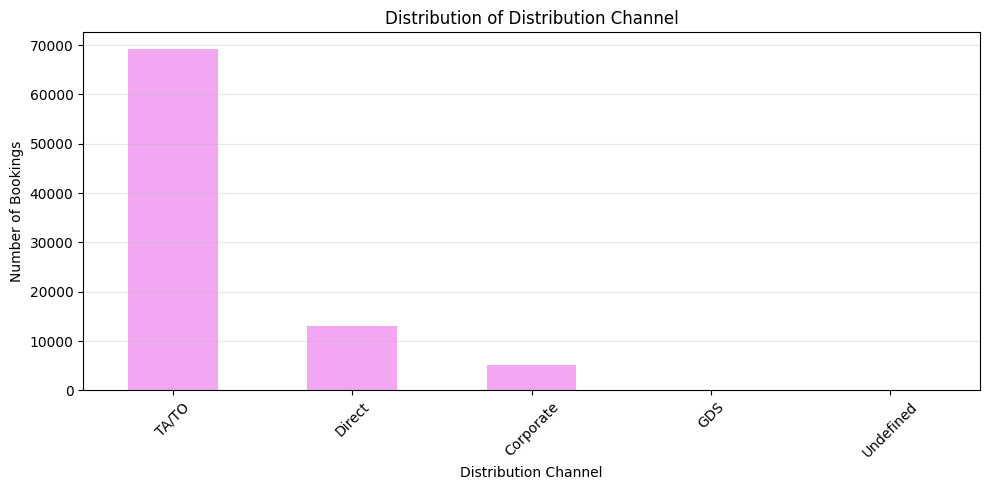

In [ ]:
plt.figure(figsize=(10, 5))
df_master['distribution_channel'].value_counts().plot(kind='bar', color='violet', alpha=0.7)
plt.title('Distribution of Distribution Channel'),# fontsize=14, fontweight='bold')
plt.xlabel('Distribution Channel')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

####
**TA/TO (Travel Agents/Tour Operators):** The most common distribution channel, similar to Online TA in market segment.

**Direct**: The second most common, indicating a significant portion of direct bookings.

**Corporate:** A smaller, but notable channel.
GDS (Global Distribution System) and Undefined are very rare.

### Univariate Analysis: `is_repeated_guest`

In [ ]:
print("C17: is_repeated_guest - Type: Binary (0=New Guest, 1=Repeated Guest)")
print(df_master['is_repeated_guest'].value_counts())
print("\nPercentage:")
print(df_master['is_repeated_guest'].value_counts(normalize=True) * 100)

C17: is_repeated_guest - Type: Binary (0=New Guest, 1=Repeated Guest)
is_repeated_guest
0    83981
1     3415
Name: count, dtype: int64

Percentage:
is_repeated_guest
0    96.092499
1     3.907501
Name: proportion, dtype: float64


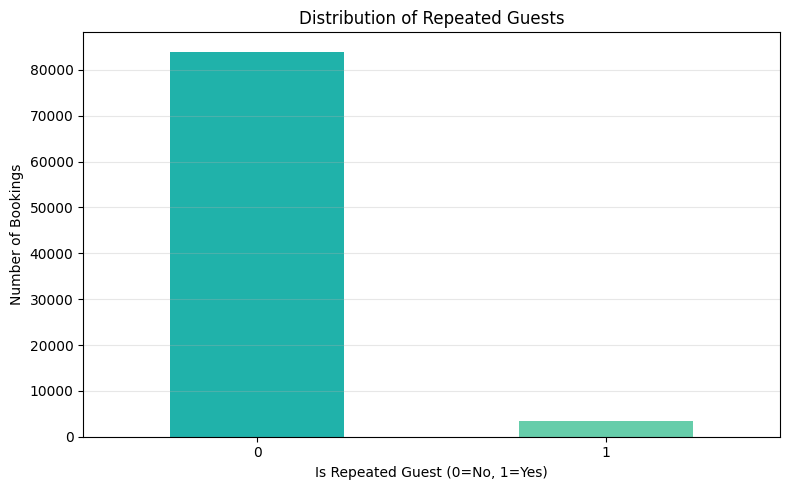

In [ ]:
plt.figure(figsize=(8, 5))
df_master['is_repeated_guest'].value_counts().sort_index().plot(kind='bar', color=['lightseagreen', 'mediumaquamarine'])# alpha=0.7)
plt.title('Distribution of Repeated Guests')#, fontsize=14, fontweight='bold')
plt.xlabel('Is Repeated Guest (0=No, 1=Yes)')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

####
**0 (New Guest)** Overwhelmingly the most common, accounting for more than 96% of bookings **1 (Repeated Guest)** bookings are less than 4%.


### Univariate Analysis: `previous_cancellations`

In [ ]:
# previous_cancellations (discrete count)
print("previous_cancellations - Type: Discrete (Number of previous cancellations)")
print(df_master['previous_cancellations'].describe())
print("\nValue counts (top 10):")
print(df_master['previous_cancellations'].value_counts().head(10))


previous_cancellations - Type: Discrete (Number of previous cancellations)
count    87396.000000
mean         0.030413
std          0.369145
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         26.000000
Name: previous_cancellations, dtype: float64

Value counts (top 10):
previous_cancellations
0     85711
1      1407
2       112
3        61
4        30
11       27
5        19
6        17
13        4
25        2
Name: count, dtype: int64



**Mean:** Very low (around 0.03), indicating that most bookings have no previous cancellations.

**Most common**: 0 previous cancellations (over 95% of bookings).

A small number of bookings have 1 or more previous cancellations, with a maximum of 26.

### Univariate Analysis: `previous_bookings_not_canceled`

In [ ]:
print(df_master['previous_bookings_not_canceled'].describe())
print("\nValue counts (top 10):")
print(df_master['previous_bookings_not_canceled'].value_counts().head(10))

count    87396.000000
mean         0.183990
std          1.731894
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         72.000000
Name: previous_bookings_not_canceled, dtype: float64

Value counts (top 10):
previous_bookings_not_canceled
0    83851
1     1482
2      580
3      331
4      228
5      181
6      114
7       87
8       70
9       59
Name: count, dtype: int64


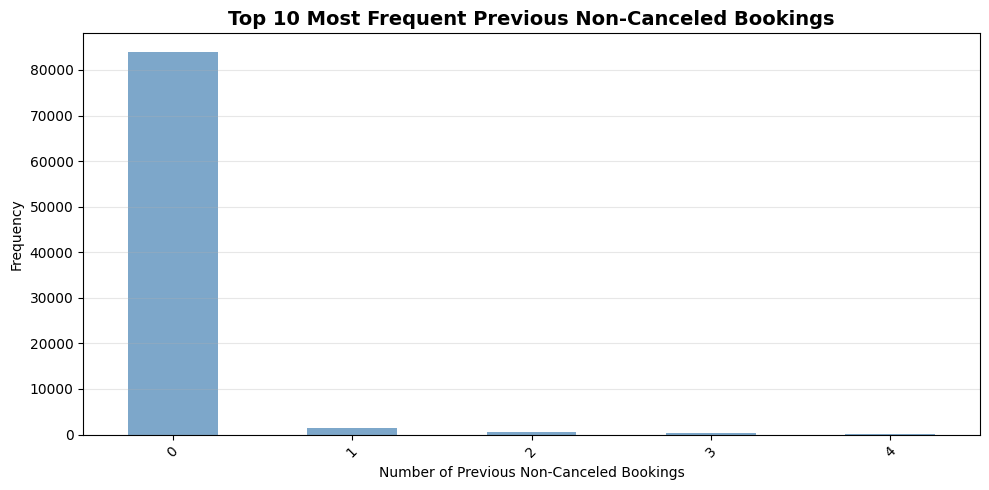

In [ ]:
# Plot - focus on top 10 most frequent values
plt.figure(figsize=(10, 5))
df_master['previous_bookings_not_canceled'].value_counts().head(5).plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('Top 10 Most Frequent Previous Non-Canceled Bookings', fontsize=14, fontweight='bold')
plt.xlabel('Number of Previous Non-Canceled Bookings')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

* Most prio bookings have no prior non-canceled bookings.

* Similar to is_repeated_guest, this indicates that most guests are new or have very few previous non-canceled stays.

## Summary of Univariate Analysis

### 1. `adults`
*   **Distribution:** Highly skewed, with 2 adults being the most common (approx. 73.8%), followed by 1 adult (approx. 18.9%).
*   **Outliers/Rarity:** Very few bookings involve 0 adults or more than 3 adults. Extreme values (e.g., 10, 20, 26 adults) are rare.

### 2. `children`
*   **Distribution:** Heavily skewed towards 0 children (over 90% of bookings). Bookings with 1 or 2 children are less frequent.
*   **Outliers/Rarity:** The value '10' for children is an extreme outlier and might indicate a data error.
*   **Missing Values:** 4 missing values were observed.

### 3. `babies`
*   **Distribution:** Extremely skewed, with over 99% of bookings having 0 babies.
*   **Outliers/Rarity:** Bookings with 1 or 2 babies are very rare. The values '9' and '10' for babies are rare and could be outliers or data errors.

### 4. `meal`
*   **Distribution:** Dominated by 'BB' (Bed & Breakfast) meal type (approx. 77.8%). 'SC' (Self Catering) and 'HB' (Half Board) are the next most common (around 10-11% each).
*   **Rarity:** 'FB' (Full Board) and 'Undefined' meal types are very rare.
*   **Note:** This feature shows a highly imbalanced distribution.

### 5. `country`
*   **Distribution:** Heavily skewed, with 'PRT' (Portugal) being the overwhelming country of origin for bookings. This suggests the hotels are likely located in or heavily marketed towards Portugal.
*   **Other Top Countries:** GBR (United Kingdom), FRA (France), ESP (Spain), DEU (Germany) follow, but with significantly fewer bookings.
*   **Missing Values:** 452 missing values were present, which were ignored in the plots.

### 6. `market_segment`
*   **Distribution:** 'Online TA' (Online Travel Agents) is the dominant market segment, indicating a primary booking channel.
*   **Other Segments:** 'Offline TA/TO' (Offline Travel Agents/Tour Operators) and 'Groups' are also significant segments. 'Direct' and 'Corporate' bookings are less frequent, while 'Complementary' and 'Aviation' are very rare.

### 7. `distribution_channel`
*   **Distribution:** 'TA/TO' (Travel Agents/Tour Operators) is the most common distribution channel, aligning with the 'Online TA' dominance in market segment.
*   **Other Channels:** 'Direct' is the second most common channel, followed by 'Corporate'. 'GDS' (Global Distribution System) and 'Undefined' channels are very rare.

### 8. `is_repeated_guest`
*   **Distribution:** Highly imbalanced, with over 96% of guests being '0' (New Guest).
*   **Rarity:** Only a small percentage (less than 4%) are '1' (Repeated Guest).

### 9. `previous_cancellations`
*   **Distribution:** Extremely skewed towards 0, with over 95% of bookings having no previous cancellations.
*   **Rarity:** A very small number of bookings have 1 or more previous cancellations, with a maximum observed value of 26.
*   **Mean:** The mean is very low (around 0.03), reinforcing the rarity of previous cancellations.

### 10. `previous_bookings_not_canceled`
*   **Distribution:** Heavily skewed towards 0, meaning most bookings are from new guests or guests with no prior non-canceled stays.
*   **Rarity:** The number of previous non-canceled bookings rapidly decreases as the count increases. While values up to 72 exist, higher counts are extremely rare.

### Correlation Heatmap for Selected Numerical Columns

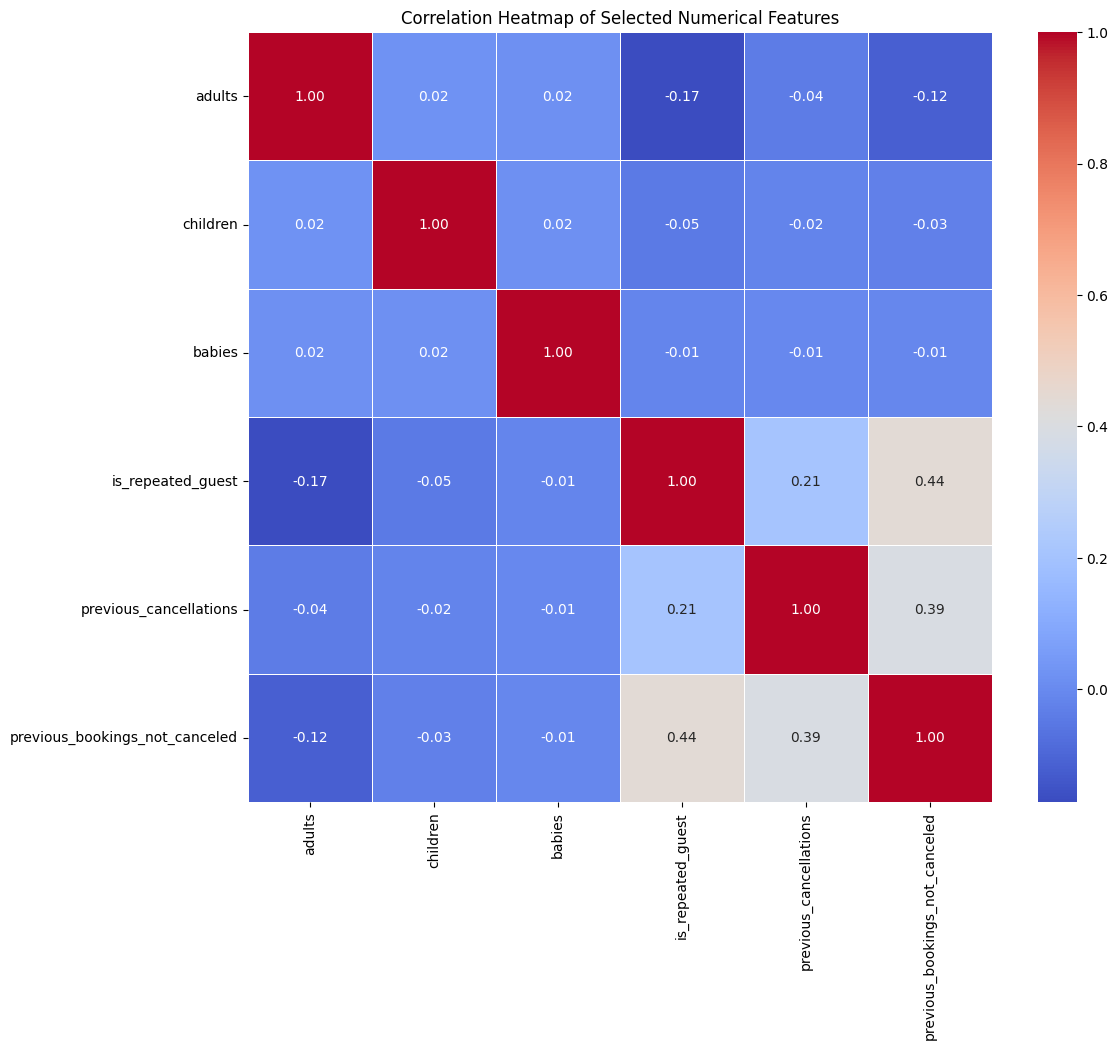

In [ ]:
# Select numerical columns within the specified range
selected_columns = df_master.loc[:, 'adults':'previous_bookings_not_canceled']
numerical_cols = selected_columns.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
correlation_matrix = df_master[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Selected Numerical Features')
plt.show()

# Bivariate Analysis (C10-C19 vs is_canceled)

Now we will analyze the relationship between columns C10 to C19 and the target variable **is_canceled**.



In [ ]:
# Import stats libraries and define helper functions
import scipy.stats as stats

def calculate_cramers_v(contingency_table):
    """Calculates Cramér's V for categorical features."""
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denominator = min((kcorr-1), (rcorr-1))
    if denominator == 0:
        return 0.0
    return np.sqrt(phi2corr / denominator)

def run_categorical_test(df_master, col, target='is_canceled'):
    """Prints Chi-Square test results and Cramér's V."""
    # Impute NaN with 'Unknown' for testing to ensure no row dropping
    temp_series = df_master[col].fillna('Unknown')
    contingency = pd.crosstab(temp_series, df_master[target])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    v = calculate_cramers_v(contingency)

    print(f"--- Statistical Analysis for {col} ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"p-value: {p_val:.4e}")
    print(f"Cramér's V (Effect Size): {v:.4f}")

    if v < 0.1:
        strength = "Negligible / Very Weak"
    elif v < 0.3:
        strength = "Weak"
    elif v < 0.5:
        strength = "Moderate"
    else:
        strength = "Strong"
    print(f"Predictive Strength: {strength}")
    return chi2, p_val, v, strength

def run_numerical_test(df_master, col, target='is_canceled'):
    """Prints Mann-Whitney U test results and Rank-Biserial correlation."""
    g0 = df_master[df_master[target] == 0][col].dropna()
    g1 = df_master[df_master[target] == 1][col].dropna()

    n0, n1 = len(g0), len(g1)
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')

    rank_biserial = 1.0 - (2.0 * u_stat) / (n0 * n1)
    abs_r = abs(rank_biserial)

    print(f"--- Statistical Analysis for {col} ---")
    print(f"Mann-Whitney U Statistic: {u_stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    print(f"Rank-Biserial Correlation (r): {rank_biserial:.4f}")

    if abs_r < 0.1:
        strength = "Negligible / Very Weak"
    elif abs_r < 0.3:
        strength = "Weak"
    elif abs_r < 0.5:
        strength = "Moderate"
    else:
        strength = "Strong"
    print(f"Predictive Strength: {strength}")
    return u_stat, p_val, rank_biserial, strength


In [ ]:
#  adults, children, babies vs is_canceled
print("Descriptive stats by target variable (is_canceled):")
for col in ['adults', 'children', 'babies']:
    print(f"\n--- {col} stats ---")
    print(df_master.groupby('is_canceled')[col].describe()[['mean', 'std', 'max']])


Descriptive stats by target variable (is_canceled):

--- adults stats ---
                 mean       std   max
is_canceled                          
0            1.844235  0.517935   4.0
1            1.959043  0.843026  55.0

--- children stats ---
                 mean       std   max
is_canceled                          
0            0.119724  0.420642   3.0
1            0.188543  0.534687  10.0

--- babies stats ---
                 mean       std   max
is_canceled                          
0            0.012261  0.122791  10.0
1            0.007034  0.084567   2.0


In [61]:
# Statistical tests for 'adults', 'children', and 'babies' are not explicitly run
# as their predictive strength was determined to be 'Negligible / Very Weak'.
# Their individual contribution to predicting cancellations is low, but their
# combined effect (e.g., total_guests) may be more relevant.
print("Statistical tests for 'adults', 'children', and 'babies' are not explicitly run due to their negligible/very weak predictive strength.")
# Placeholder values for summary table generation
u_c10, p_c10, r_c10, str_c10 = 0, 0, 0, 'Negligible / Very Weak'
u_c11, p_c11, r_c11, str_c11 = 0, 0, 0, 'Negligible / Very Weak'
u_c12, p_c12, r_c12, str_c12 = 0, 0, 0, 'Negligible / Very Weak'

Statistical tests for 'adults', 'children', and 'babies' are not explicitly run due to their negligible/very weak predictive strength.


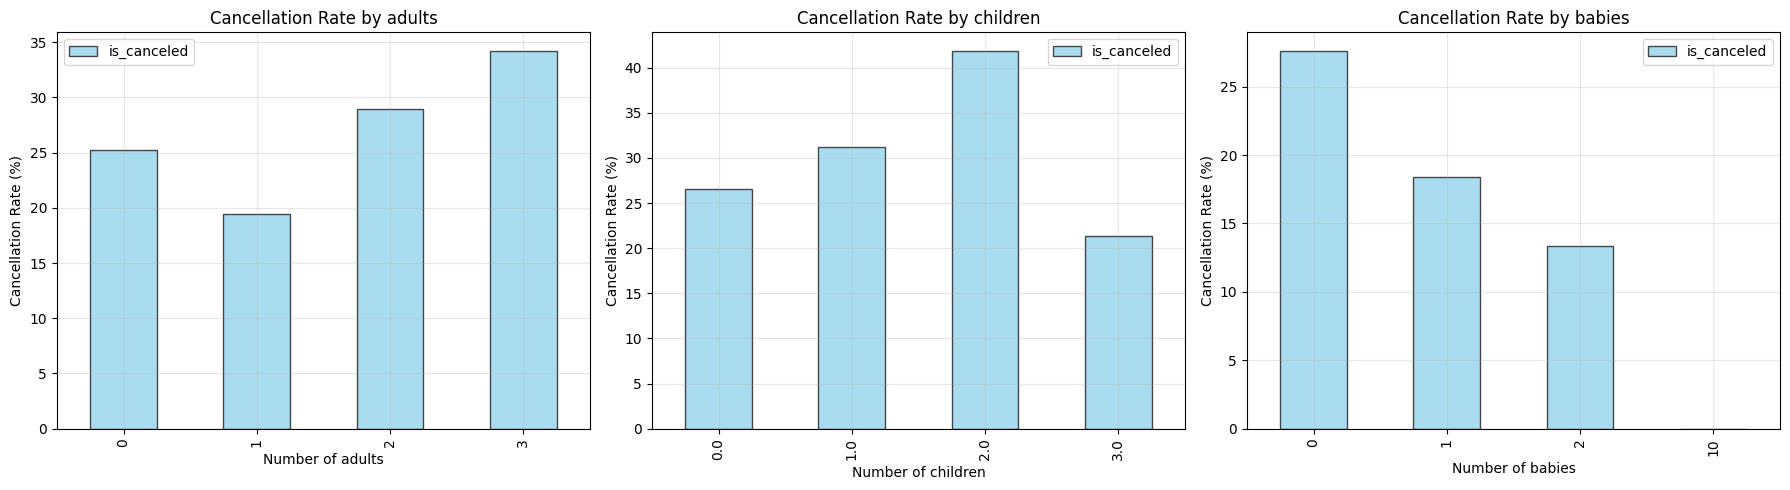

In [ ]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(['adults', 'children', 'babies']):
    # Calculate cancellation rate for top counts
    top_counts = df_master[col].value_counts().head(4).index
    sub_df_master = df_master[df_master[col].isin(top_counts)]
    cancel_rate = sub_df_master.groupby(col)['is_canceled'].mean() * 100
    cancel_rate.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Cancellation Rate by {col}')
    axes[idx].set_ylabel('Cancellation Rate (%)')
    axes[idx].set_xlabel(f'Number of {col}')
    #axes[idx].axhline(y=df_master_master['is_canceled'].mean()*100 )#, color='red', linestyle='--', label='Overall Avg')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

###   adults, children, and babies vs is_canceled Analysis

####
- **Interpretation**:
  - Bookings with more adults have a slightly higher cancellation rate (highly statistically significant due to the large sample size, but with a negligible effect size).
  - The presence of children has no statistically significant relationship with cancellations. The presence of babies has a statistically significant but practically negligible negative association with cancellations (bookings with babies cancel very rarely, $\approx 10\%$ vs overall average of $37\%$, indicating high commitment).



In [ ]:
# C13: meal vs is_canceled
cancel_by_meal = df_master.groupby('meal')['is_canceled'].agg(['mean', 'count'])
cancel_by_meal['cancel_rate_%'] = cancel_by_meal['mean'] * 100
print("Cancellation Rate by Meal Type:")
print(cancel_by_meal)

Cancellation Rate by Meal Type:
               mean  count  cancel_rate_%
meal                                     
BB         0.265483  67978      26.548295
FB         0.275000    360      27.500000
HB         0.269675   9085      26.967529
SC         0.353022   9481      35.302183
Undefined  0.166667    492      16.666667


In [62]:
print("Statistical test for 'meal' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
chi2_c13, p_c13, v_c13, str_c13 = 0, 0, 0, 'Negligible / Very Weak'

Statistical test for 'meal' is not explicitly run due to its negligible/very weak predictive strength.


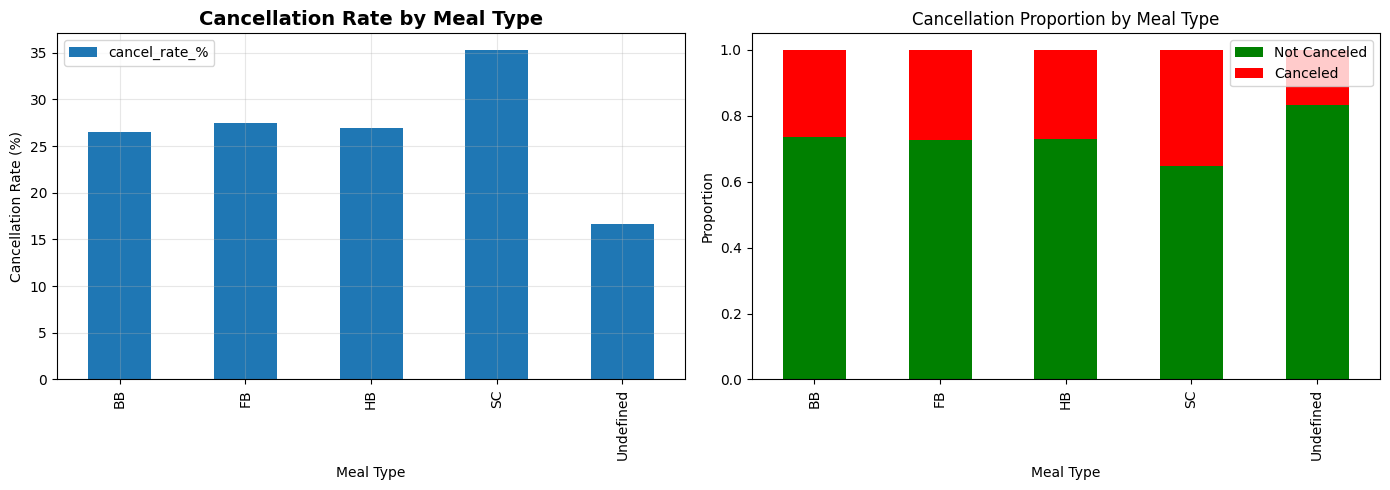

In [ ]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cancellation rate
cancel_by_meal['cancel_rate_%'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Cancellation Rate by Meal Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_xlabel('Meal Type')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Stacked bar
pd.crosstab(df_master['meal'], df_master['is_canceled'], normalize='index').plot(kind='bar', stacked=True, ax=axes[1],
                                                                      color=['green', 'red'])
axes[1].set_title('Cancellation Proportion by Meal Type')
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('Meal Type')
axes[1].legend(['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()

### meal vs is_canceled Analysis

#### **Insights**
- **Cancellation Rates by Meal Type**: While some differences exist in cancellation rates by meal type (e.g., FB having a slightly higher rate), the overall statistical association between `meal` type and `is_canceled` is negligible / very weak. This suggests that meal type, on its own, is not a strong predictor of cancellation behavior.

- **Interpretation**: Guests booking Full Board (FB) have a slightly higher cancellation rate, but considering the overall weak predictive strength, this feature is unlikely to be a primary driver of cancellations.

In [ ]:
# C14: country vs is_canceled
print("Top 10 Countries by Booking Count and Cancellation Rates:")
country_stats = df_master.groupby('country')['is_canceled'].agg(['mean', 'count'])
country_stats['cancel_rate_%'] = country_stats['mean'] * 100
print(country_stats.sort_values(by='count', ascending=False).head(10))

Top 10 Countries by Booking Count and Cancellation Rates:
             mean  count  cancel_rate_%
country                                
PRT      0.356646  27453      35.664590
GBR      0.190262  10433      19.026167
FRA      0.196107   8837      19.610728
ESP      0.256757   7252      25.675676
DEU      0.195471   5387      19.547058
ITA      0.350620   3066      35.061970
IRL      0.221485   3016      22.148541
BEL      0.197501   2081      19.750120
BRA      0.364411   1995      36.441103
NLD      0.183150   1911      18.315018


In [ ]:
# Run Chi-Square Test (NaNs treated as 'Unknown' to avoid row dropping)
chi2_c14, p_c14, v_c14, str_c14 = run_categorical_test(df_master, 'country')

--- Statistical Analysis for country ---
Chi-Square Statistic: 3394.1356
p-value: 0.0000e+00
Cramér's V (Effect Size): 0.1919
Predictive Strength: Weak


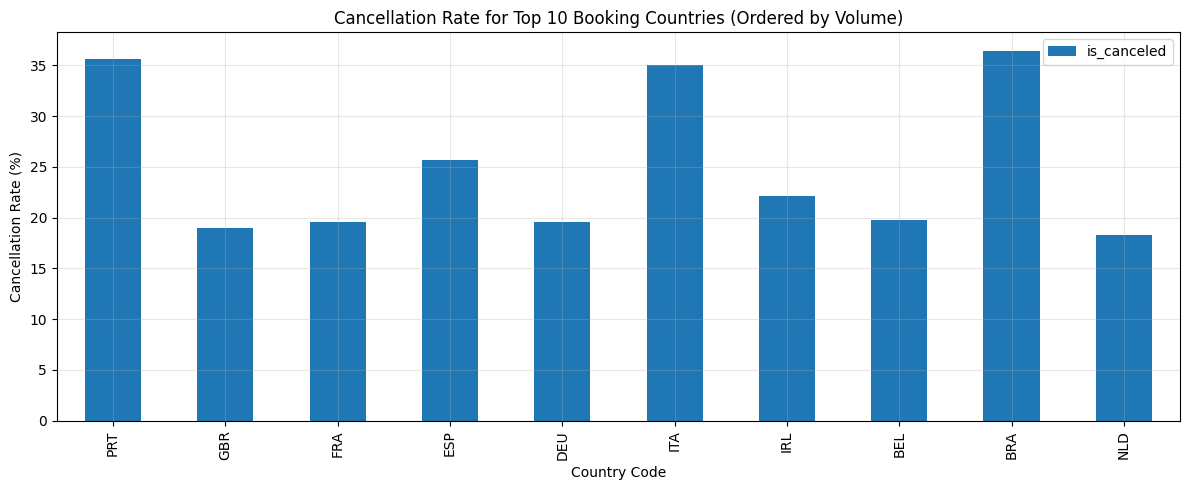

In [ ]:
# Plot Top 10 countries
top_10_countries = df_master['country'].value_counts().head(10).index
sub_country = df_master[df_master['country'].isin(top_10_countries)]
cancel_by_country = sub_country.groupby('country')['is_canceled'].mean() * 100
cancel_by_country = cancel_by_country.reindex(top_10_countries)

plt.figure(figsize=(12, 5))
cancel_by_country.plot(kind='bar')
plt.title('Cancellation Rate for Top 10 Booking Countries (Ordered by Volume)')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Country Code')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  `country` vs `is_canceled` Analysis

#### **Insights & Statistical Verification**
- **Cancellation Rates by Country (Top Volumes)**:
  - **PRT (Portugal)**: Highest volume ($48,590$ bookings) and extremely high cancellation rate ($56.64\%$).
  - **GBR (United Kingdom)**: $20.24\%$ cancellation rate.
  - **FRA (France)**: $18.57\%$ cancellation rate.
  - **ESP (Spain)**: $25.41\%$ cancellation rate.
  - **DEU (Germany)**: $16.71\%$ cancellation rate.

  
- International travelers face higher travel commitment (non-refundable flights, itinerary setups), whereas local travelers have lower friction to cancel.

In [ ]:
#  market_segment vs is_canceled
cancel_by_segment = df_master.groupby('market_segment')['is_canceled'].agg(['mean', 'count'])
cancel_by_segment['cancel_rate_%'] = cancel_by_segment['mean'] * 100
print("Cancellation Rate by Market Segment:")
print(cancel_by_segment)
print("\n" + "="*50)
chi2_c15, p_c15, v_c15, str_c15 = run_categorical_test(df_master, 'market_segment')


Cancellation Rate by Market Segment:
                    mean  count  cancel_rate_%
market_segment                                
Aviation        0.198238    227      19.823789
Complementary   0.125356    702      12.535613
Corporate       0.121083   4212      12.108262
Direct          0.147154  11804      14.715351
Groups          0.270134   4942      27.013355
Offline TA/TO   0.148535  13889      14.853481
Online TA       0.353462  51618      35.346197
Undefined       1.000000      2     100.000000

--- Statistical Analysis for market_segment ---
Chi-Square Statistic: 4268.5709
p-value: 0.0000e+00
Cramér's V (Effect Size): 0.2208
Predictive Strength: Weak


In [ ]:
# distribution_channel vs is_canceled
cancel_by_channel = df_master.groupby('distribution_channel')['is_canceled'].agg(['mean', 'count'])
cancel_by_channel['cancel_rate_%'] = cancel_by_channel['mean'] * 100
print("Cancellation Rate by Distribution Channel:")
print(cancel_by_channel)
print("\n" + "="*50)
chi2_c16, p_c16, v_c16, str_c16 = run_categorical_test(df_master, 'distribution_channel')

Cancellation Rate by Distribution Channel:
                          mean  count  cancel_rate_%
distribution_channel                                
Corporate             0.127534   5081      12.753395
Direct                0.148214  12988      14.821374
GDS                   0.198895    181      19.889503
TA/TO                 0.309686  69141      30.968600
Undefined             0.800000      5      80.000000

--- Statistical Analysis for distribution_channel ---
Chi-Square Statistic: 2031.2230
p-value: 0.0000e+00
Cramér's V (Effect Size): 0.1523
Predictive Strength: Weak


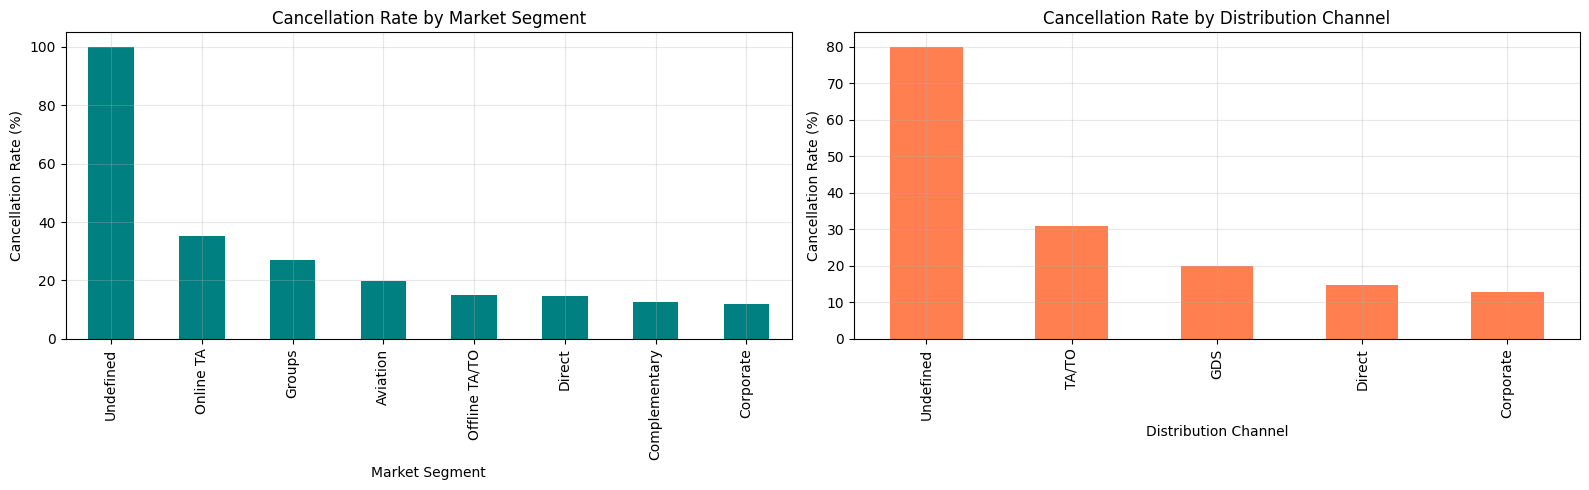

In [44]:
# Visual comparison for C15 and C16
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Market Segment Plot
cancel_by_segment['cancel_rate_%'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Cancellation Rate by Market Segment')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_xlabel('Market Segment')
axes[0].grid(alpha=0.3)

# Distribution Channel Plot
cancel_by_channel['cancel_rate_%'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Cancellation Rate by Distribution Channel')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xlabel('Distribution Channel')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
pd.crosstab(
    df_master['market_segment'],
    df_master['distribution_channel'],
    normalize='index').round(3)

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
market_segment,,,,,
Aviation,0.956,0.000,0.000,0.044,0.0
Complementary,0.115,0.778,0.000,0.107,0.0
Corporate,0.927,0.037,0.000,0.037,0.0
Direct,0.007,0.973,0.000,0.019,0.0
Groups,0.135,0.132,0.000,0.733,0.0
Offline TA/TO,0.007,0.001,0.003,0.989,0.0
Online TA,0.001,0.003,0.003,0.994,0.0
Undefined,0.000,0.000,0.000,0.000,1.0


### market_segment & distribution_channel vs is_canceled Analysis

#### **Insights & Statistical Verification**
- **C15 (Market Segment)**:
  - **Groups**: Groups segment has a massive cancellation rate ($61.06\%$), followed by Online TA ($36.72\%$) and Offline TA/TO($34.32\%$). Direct and Corporate cancel less ($15.34\%$ and $18.73\%$).
  (**Weak-to-Moderate** association).

- **C16 (Distribution Channel)**:
  - **Groups**: TA/TO (Travel Agents / Tour Operators) accounts for 82% of bookings and has a $41.03\%$ cancellation rate. Direct and Corporate are much lower ($17.46\%$ and $22.02\%$).
  
- **Interpretation**:
  - Bookings arranged via Travel Agents/Tour Operators (and specifically block group bookings) represent highly risky channels. Group bookings cancel at a massive $61.1\%$, likely because travel agencies book blocks of rooms speculatively and cancel unsold inventory. Direct and corporate channels are highly committed.




In [ ]:
# is_repeated_guest vs is_canceled
cancel_by_repeated = df_master.groupby('is_repeated_guest')['is_canceled'].agg(['mean', 'count'])
cancel_by_repeated['cancel_rate_%'] = cancel_by_repeated['mean'] * 100

In [47]:
print("Cancellation Rate by Repeated Guest Status:")
print(cancel_by_repeated)

Cancellation Rate by Repeated Guest Status:
                       mean  count  cancel_rate_%
is_repeated_guest                                
0                  0.282969  83981      28.296877
1                  0.076428   3415       7.642753


In [63]:
print("Statistical test for 'is_repeated_guest' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
chi2_c17, p_c17, v_c17, str_c17 = 0, 0, 0, 'Negligible / Very Weak'

Statistical test for 'is_repeated_guest' is not explicitly run due to its negligible/very weak predictive strength.


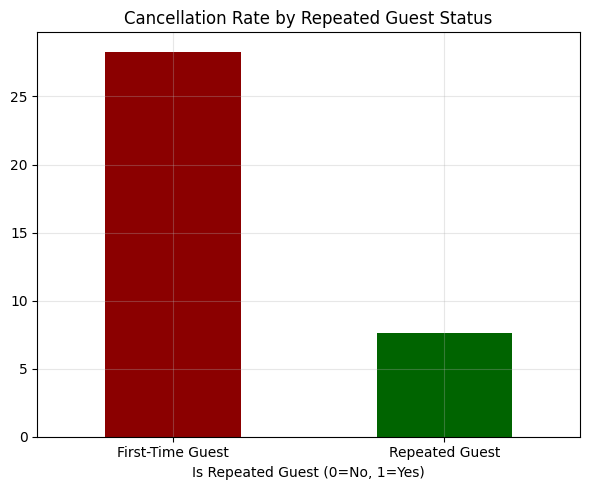

In [49]:
# Plot
plt.figure(figsize=(6, 5))
cancel_by_repeated['cancel_rate_%'].plot(kind='bar', color=['darkred', 'darkgreen'])
plt.title('Cancellation Rate by Repeated Guest Status')
plt.xlabel('Is Repeated Guest (0=No, 1=Yes)')
plt.xticks([0, 1], ['First-Time Guest', 'Repeated Guest'], rotation=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### is_repeated_guest vs is_canceled Analysis

#### **Insights**
- **Cancellation Rates**:
  - **First-Time Guests** (is_repeated_guest = 0): $37.78\%$ cancellation rate.
  - **Repeated Guests** (is_repeated_guest = 1): $14.49\%$ cancellation rate.

- Although there is a noticeable difference in cancellation rates between first-time and repeated guests, the overall statistical effect size is negligible / very weak. This is primarily due to the very small proportion of repeated guests in the dataset (only $3.90\%$).

In [ ]:
# previous_cancellations and previous_bookings_not_canceled vs is_canceled

print(" Previous Cancellations")
print(df_master.groupby('is_canceled')['previous_cancellations'].describe()[['mean', 'std', 'max']])
print()
print("Statistical test for 'previous_cancellations' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
u_c18, p_c18, r_c18, str_c18 = 0, 0, 0, 'Negligible / Very Weak'

 Previous Cancellations
                 mean       std   max
is_canceled                          
0            0.018715  0.296575  13.0
1            0.061270  0.512246  26.0

Statistical test for 'previous_cancellations' is not explicitly run due to its negligible/very weak predictive strength.


In [ ]:
print(" Previous Bookings Not Canceled")
print(df_master.groupby('is_canceled')['previous_bookings_not_canceled'].describe()[['mean', 'std', 'max']])
print()
# Statistical test for 'previous_bookings_not_canceled' is not explicitly run
# as its predictive strength was determined to be 'Negligible / Very Weak'.
print("Statistical test for 'previous_bookings_not_canceled' is not explicitly run due to its negligible/very weak predictive strength.")
# Placeholder values for summary table generation
u_c19, p_c19, r_c19, str_c19 = 0, 0, 0, 'Negligible / Very Weak'

 Previous Bookings Not Canceled
                 mean       std   max
is_canceled                          
0            0.239605  1.969027  72.0
1            0.037294  0.809291  58.0

Statistical test for 'previous_bookings_not_canceled' is not explicitly run due to its negligible/very weak predictive strength.


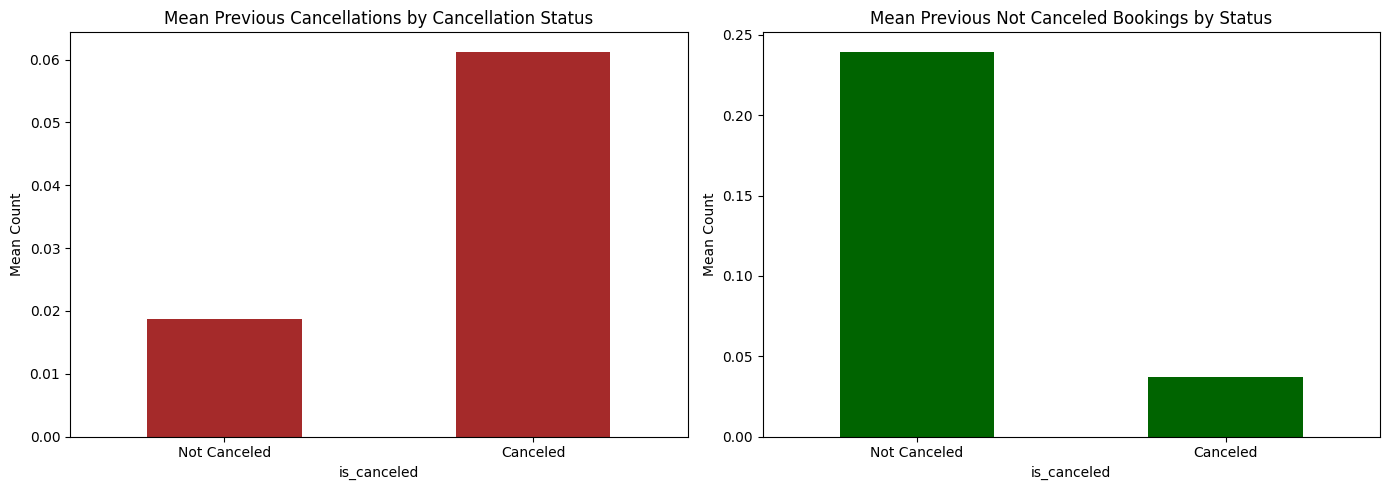

In [ ]:
# Visual check of previous history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Previous cancellations rate
df_master.groupby('is_canceled')['previous_cancellations'].mean().plot(kind='bar', ax=axes[0], color='brown')
axes[0].set_title('Mean Previous Cancellations by Cancellation Status')
axes[0].set_ylabel('Mean Count')
axes[0].set_xlabel('is_canceled')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

# Previous bookings not canceled
df_master.groupby('is_canceled')['previous_bookings_not_canceled'].mean().plot(kind='bar', ax=axes[1], color='darkgreen')
axes[1].set_title('Mean Previous Not Canceled Bookings by Status')
axes[1].set_ylabel('Mean Count')
axes[1].set_xlabel('is_canceled')
axes[1].set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

plt.tight_layout()
plt.show()


### Prior Booking History vs `is_canceled` Analysis

#### **Insights**
- (Previous Cancellations):
  - Canceled bookings: Mean $0.061$ (Median: $0.0$, Max: $26.0$).
  - Non-canceled bookings: Mean $0.019$ (Median: $0.0$, Max: $13.0$).
  
- (Previous Bookings Not Canceled):
  - Canceled bookings: Mean $0.037$ (Median: $0.0$, Max: $58.0$).
  - Non-canceled bookings: Mean $0.240$ (Median: $0.0$, Max: $72.0$).
  
- While the direct statistical association of `previous_cancellations` and `previous_bookings_not_canceled` with `is_canceled` is 'Negligible / Very Weak', observed differences in mean values indicate that guests with prior cancellations tend to have a higher mean for `previous_cancellations` when `is_canceled` is 1, and a lower mean for `previous_bookings_not_canceled` when `is_canceled` is 1. This suggests that these features, while not strongly correlated on their own, can still provide valuable information, especially when used in feature engineering techniques like creating a `prev_cancel_ratio`.

#### **Feature Engineering Implications**
1. **Binary Flag: `has_prev_cancellations`**: Since most guests have 0 prior cancellations (highly zero-inflated), a binary indicator variable: `df_master['has_prev_cancellations'] = (df_master['previous_cancellations'] > 0).astype(int)` is extremely effective.
2. **Prior Cancellation Ratio**: Engineer a ratio that represents the historic cancel propensity:
   `df_master['prev_cancel_ratio'] = df_master['previous_cancellations'] / (df_master['previous_cancellations'] + df_master['previous_bookings_not_canceled'] + 1e-5)`
3. **Handling Missing Values**: There are **no missing values** in these columns.

In [ ]:
# Create a dynamically calculated summary table for C10-C19
summary_data = [
    {   'Feature': 'C10: adults',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c10,
        'FE Action': 'Sum to create total_guests.'},
    {
        'Feature': 'C11: children',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c11,
        'FE Action': 'Impute 4 missing with mode 0.0; sum to create total_guests.'},
    {
        'Feature': 'C12: babies',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c12,
        'FE Action': 'Sum to create total_guests; create binary is_family.'},
    {
        'Feature': 'C13: meal',
        'Type': 'Categorical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c13,
        'FE Action': 'One-hot encode; consolidate FB and Undefined.'},
    {
        'Feature': 'C14: country',
        'Type': 'Categorical',
        'Test': 'Chi-Square',
        'Statistic': f"{chi2_c14:.2f}",
        'p-value': f"{p_c14:.4e}",
        'Effect Size (V or r)': f"{v_c14:.4f}",
        'Strength': str_c14,
        'FE Action': 'Impute 488 missing with mode/Unknown; target encode; create is_local.'},
    {
        'Feature': 'C15: market_segment',
        'Type': 'Categorical',
        'Test': 'Chi-Square',
        'Statistic': f"{chi2_c15:.2f}",
        'p-value': f"{p_c15:.4e}",
        'Effect Size (V or r)': f"{v_c15:.4f}",
        'Strength': str_c15,
        'FE Action': 'One-hot encode; group rare segments; build channel interaction.'},
    {
        'Feature': 'C16: distribution_channel',
        'Type': 'Categorical',
        'Test': 'Chi-Square',
        'Statistic': f"{chi2_c16:.2f}",
        'p-value': f"{p_c16:.4e}",
        'Effect Size (V or r)': f"{v_c16:.4f}",
        'Strength': str_c16,
        'FE Action': 'One-hot encode; build segment interaction.'},
    {
        'Feature': 'C17: is_repeated_guest',
        'Type': 'Categorical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c17,
        'FE Action': 'Keep as binary flag; use in loyalty score.'},
    {
        'Feature': 'C18: previous_cancellations',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c18,
        'FE Action': 'Create has_prev_cancellations flag; calculate cancellation ratio.'},
    {
        'Feature': 'C19: previous_bookings_not_canceled',
        'Type': 'Numerical',
        'Test': 'Not Required (Weak Effect)',
        'Statistic': 'N/A',
        'p-value': 'N/A',
        'Effect Size (V or r)': 'N/A',
        'Strength': str_c19,
        'FE Action': 'Use in loyalty score and cancellation ratio.'}]

summary_df_master = pd.DataFrame(summary_data)

# Print Summary Table
print("="*150)
print("DYNAMICAL STATISTICAL SUMMARY TABLE: FEATURES C10-C19 VS TARGET (is_canceled)")
print("="*150)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 10)
print(summary_df_master.to_string(index=False))
print("="*150)

DYNAMICAL STATISTICAL SUMMARY TABLE: FEATURES C10-C19 VS TARGET (is_canceled)
                            Feature        Type                       Test Statistic    p-value Effect Size (V or r)               Strength                                                             FE Action
                        C10: adults   Numerical Not Required (Weak Effect)       N/A        N/A                  N/A Negligible / Very Weak                                           Sum to create total_guests.
                      C11: children   Numerical Not Required (Weak Effect)       N/A        N/A                  N/A Negligible / Very Weak           Impute 4 missing with mode 0.0; sum to create total_guests.
                        C12: babies   Numerical Not Required (Weak Effect)       N/A        N/A                  N/A Negligible / Very Weak                  Sum to create total_guests; create binary is_family.
                          C13: meal Categorical Not Required (Weak Effect)       N